# 05. Reporte ejecutivo

Este cuaderno construye un reporte de acceso rápido para responder preguntas simples sobre la serie:

- cuántas huelgas hubo por año
- qué proporción fue ilegal
- en qué sector se concentraron más
- en qué territorio se concentraron más
- qué regiones concentraron más huelgas por año
- cuál fue el sector dominante dentro de cada región cuando existe el cruce `sector x territorio`


In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if (ROOT / 'bases').exists() and (ROOT / 'notebooks').exists():
    project_root = ROOT
else:
    project_root = ROOT.parent

REPORTES = project_root / 'bases' / 'reportes'
SCRIPTS = project_root / 'scripts'

if not (REPORTES / 'resumen_ejecutivo_anual.csv').exists():
    import subprocess, sys
    subprocess.run([sys.executable, str(SCRIPTS / 'build_executive_report_outputs.py')], check=True, cwd=project_root)

resumen_anual = pd.read_csv(REPORTES / 'resumen_ejecutivo_anual.csv')
resumen_region = pd.read_csv(REPORTES / 'resumen_region_anual.csv')
resumen_region_sector = pd.read_csv(REPORTES / 'resumen_region_sector_dominante_2001_2024.csv')


## Resumen anual ejecutivo

In [2]:
resumen_anual.head(10)

,anio,huelgas_total,trabajadores_total,horas_total,sector_principal_huelgas,sector_principal_huelgas_valor,sector_principal_trabajadores,sector_principal_horas,territorio_principal_huelgas,territorio_principal_huelgas_valor,territorio_principal_trabajadores,territorio_principal_horas,huelgas_ilegal,huelgas_procedente,huelgas_total_observado,pct_ilegal_huelgas,pct_sector_principal_huelgas,pct_territorio_principal_huelgas
0,1994,168.0,62940.0,1936647.0,manufactura,65.0,10890.0,641020.0,lima,101.0,36975.0,1048396.0,NaN,NaN,NaN,NaN,0.386905,0.601190
1,1995,102.0,28182.0,1048753.0,mineria,37.0,14214.0,286656.0,lima,45.0,15029.0,442042.0,NaN,NaN,NaN,NaN,0.362745,0.441176
2,1996,77.0,36242.0,1399886.0,construccion,21.0,15063.0,219400.0,lima,26.0,20231.0,273540.0,70.0,7.0,77.0,0.909091,0.272727,0.337662
3,1997,66.0,19196.0,319414.0,construccion,22.0,6507.0,165832.0,lima,20.0,11544.0,168938.0,65.0,1.0,66.0,0.984848,0.333333,0.303030
4,1998,58.0,17333.0,323168.0,manufactura,15.0,1698.0,110704.0,lima,23.0,9395.0,193080.0,55.0,3.0,58.0,0.948276,0.258621,0.396552
5,1999,71.0,52080.0,724260.0,transporte,22.0,3225.0,272096.0,lima,25.0,23677.0,293252.0,69.0,2.0,71.0,0.971831,0.309859,0.352113
6,2000,37.0,5280.0,181691.0,mineria,9.0,1323.0,18576.0,lambayeque,7.0,1211.0,18543.0,36.0,1.0,37.0,0.972973,0.243243,0.189189
7,2001,40.0,11050.0,488930.0,mineria,15.0,2121.0,70008.0,lima_provincia,15.0,1350.0,77178.0,37.0,3.0,40.0,0.925000,0.375000,0.375000
8,2002,64.0,22925.0,912648.0,mineria,20.0,7712.0,376768.0,junin,14.0,2743.0,105224.0,60.0,4.0,64.0,0.937500,0.312500,0.218750
9,2003,68.0,37323.0,881362.0,manufactura,21.0,9099.0,163368.0,lima_provincia,19.0,15840.0,468774.0,64.0,4.0,68.0,0.941176,0.308824,0.279412


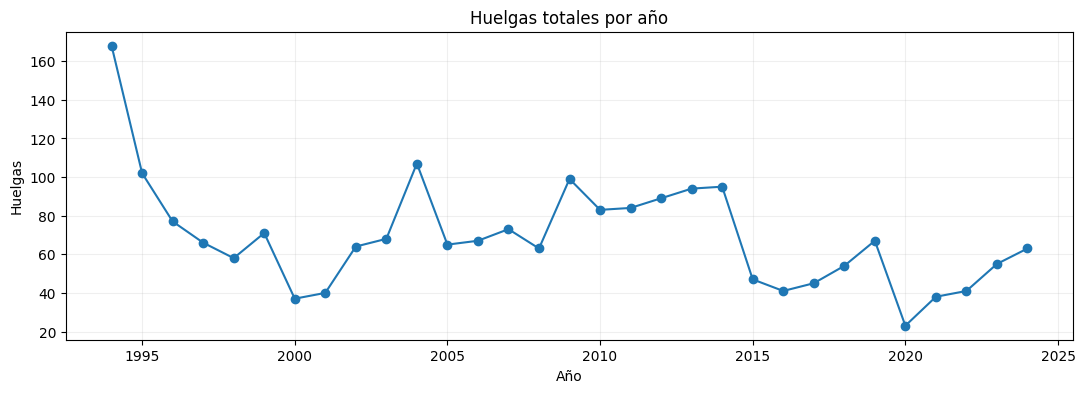

In [3]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(resumen_anual['anio'], resumen_anual['huelgas_total'], marker='o')
ax.set_title('Huelgas totales por año')
ax.set_xlabel('Año')
ax.set_ylabel('Huelgas')
ax.grid(alpha=0.2)
plt.show()


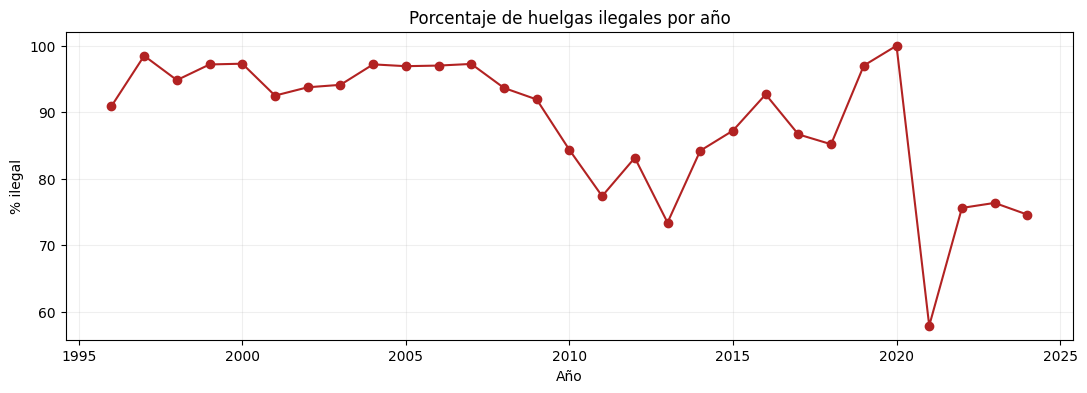

In [4]:
legalidad = resumen_anual[resumen_anual['pct_ilegal_huelgas'].notna()].copy()
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(legalidad['anio'], legalidad['pct_ilegal_huelgas'] * 100, marker='o', color='#b22222')
ax.set_title('Porcentaje de huelgas ilegales por año')
ax.set_xlabel('Año')
ax.set_ylabel('% ilegal')
ax.grid(alpha=0.2)
plt.show()


## Sector y territorio principal por año

La tabla siguiente sirve como vista ejecutiva compacta de cada año.


In [5]:
columnas = [
    'anio',
    'huelgas_total',
    'pct_ilegal_huelgas',
    'sector_principal_huelgas',
    'sector_principal_huelgas_valor',
    'territorio_principal_huelgas',
    'territorio_principal_huelgas_valor',
]
vista = resumen_anual[columnas].copy()
vista['pct_ilegal_huelgas'] = (vista['pct_ilegal_huelgas'] * 100).round(2)
vista


,anio,huelgas_total,pct_ilegal_huelgas,sector_principal_huelgas,sector_principal_huelgas_valor,territorio_principal_huelgas,territorio_principal_huelgas_valor
0,1994,168.0,NaN,manufactura,65.0,lima,101.0
1,1995,102.0,NaN,mineria,37.0,lima,45.0
2,1996,77.0,90.91,construccion,21.0,lima,26.0
3,1997,66.0,98.48,construccion,22.0,lima,20.0
4,1998,58.0,94.83,manufactura,15.0,lima,23.0
5,1999,71.0,97.18,transporte,22.0,lima,25.0
6,2000,37.0,97.30,mineria,9.0,lambayeque,7.0
7,2001,40.0,92.50,mineria,15.0,lima_provincia,15.0
8,2002,64.0,93.75,mineria,20.0,junin,14.0
9,2003,68.0,94.12,manufactura,21.0,lima_provincia,19.0


## Regiones con más huelgas en la serie

In [6]:
top_regiones = (
    resumen_region.groupby('region', as_index=False)['huelgas']
    .sum()
    .sort_values('huelgas', ascending=False)
    .head(10)
)
top_regiones


,region,huelgas
19,lima_metropolitana,377.0
20,lima_provincia,279.0
18,lima,240.0
3,arequipa,182.0
16,lambayeque,126.0
27,piura,117.0
14,junin,113.0
15,la_libertad,102.0
0,ancash,83.0
26,pasco,83.0


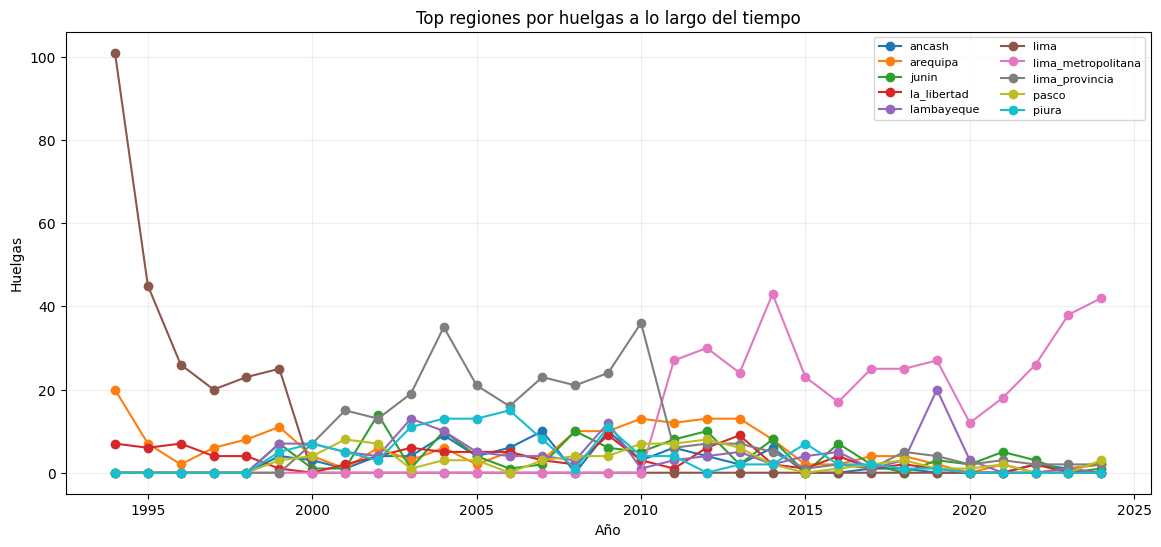

In [7]:
top_regiones_lista = top_regiones['region'].tolist()
serie_top = resumen_region[resumen_region['region'].isin(top_regiones_lista)].copy()
pivot_top = serie_top.pivot(index='anio', columns='region', values='huelgas').fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
for col in pivot_top.columns:
    ax.plot(pivot_top.index, pivot_top[col], marker='o', linewidth=1.5, label=col)
ax.set_title('Top regiones por huelgas a lo largo del tiempo')
ax.set_xlabel('Año')
ax.set_ylabel('Huelgas')
ax.grid(alpha=0.2)
ax.legend(ncol=2, fontsize=8)
plt.show()


## Tabla regional por año

Aquí puedes cambiar `anio_objetivo` para ver el detalle exacto de un año.


In [8]:
anio_objetivo = 2024
tabla_region_anio = (
    resumen_region[resumen_region['anio'] == anio_objetivo]
    .sort_values(['huelgas', 'trabajadores_comprendidos'], ascending=False)
    [['anio', 'region', 'huelgas', 'participacion_huelgas_anual', 'trabajadores_comprendidos', 'horas_hombre_perdidas', 'rank_region_huelgas']]
    .copy()
)
tabla_region_anio['participacion_huelgas_anual'] = (tabla_region_anio['participacion_huelgas_anual'] * 100).round(2)
tabla_region_anio


,anio,region,huelgas,participacion_huelgas_anual,trabajadores_comprendidos,horas_hombre_perdidas,rank_region_huelgas
446,2024,lima_metropolitana,42.0,66.67,72555.0,2158020.0,1
447,2024,cajamarca,6.0,9.52,2725.0,39032.0,2
448,2024,pasco,3.0,4.76,521.0,8912.0,3
451,2024,ica,2.0,3.17,287.0,15928.0,6
450,2024,arequipa,2.0,3.17,147.0,1176.0,5
453,2024,tumbes,2.0,3.17,146.0,18224.0,8
449,2024,ancash,2.0,3.17,126.0,1136.0,4
452,2024,lima_provincia,2.0,3.17,122.0,37088.0,7
455,2024,junin,1.0,1.59,50.0,14800.0,10
454,2024,apurimac,1.0,1.59,25.0,1200.0,9


## Sector dominante dentro de cada región

Este bloque usa la base complementaria `sector x territorio`, por lo que cubre `2001-2024`.


In [9]:
resumen_region_sector.head(10)

,anio,region,sector_principal_region,sector_principal_huelgas,sector_principal_trabajadores,sector_principal_horas,huelgas_region_total,trabajadores_region_total,horas_region_total,participacion_sector_principal_huelgas
0,2001,arequipa,constru_ccion,1.0,257.0,2056.0,1.0,257.0,2056.0,1.000000
1,2001,callao,constru_ccion,1.0,19.0,912.0,1.0,19.0,912.0,1.000000
2,2001,cusco,constru_ccion,0.0,25.0,200.0,0.0,25.0,200.0,NaN
3,2001,huancavelica,mineria,1.0,248.0,7936.0,1.0,248.0,7936.0,1.000000
4,2001,huanuco,mineria,1.0,46.0,5520.0,1.0,46.0,5520.0,1.000000
5,2001,lima_provincia,mineria,4.0,503.0,37528.0,13.0,1315.0,74618.0,0.307692
6,2001,pasco,mineria,7.0,592.0,7848.0,8.0,1042.0,22248.0,0.875000
7,2001,piura,constru_ccion,2.0,274.0,11080.0,3.0,678.0,14312.0,0.666667
8,2002,arequipa,electricidad_agua,1.0,121.0,968.0,1.0,882.0,40832.0,1.000000
9,2002,ayacucho,transporte,0.0,2.0,192.0,0.0,2.0,192.0,NaN


In [10]:
anio_region_objetivo = 2024
tabla_sector_region = (
    resumen_region_sector[resumen_region_sector['anio'] == anio_region_objetivo]
    .sort_values(['sector_principal_huelgas', 'huelgas_region_total'], ascending=False)
    [['anio', 'region', 'sector_principal_region', 'sector_principal_huelgas', 'participacion_sector_principal_huelgas', 'huelgas_region_total']]
    .copy()
)
tabla_sector_region['participacion_sector_principal_huelgas'] = (tabla_sector_region['participacion_sector_principal_huelgas'] * 100).round(2)
tabla_sector_region


,anio,region,sector_principal_region,sector_principal_huelgas,participacion_sector_principal_huelgas,huelgas_region_total


## Archivos exportados

Este notebook se apoya en tres tablas que quedan listas para consulta o exportación:

- `bases/reportes/resumen_ejecutivo_anual.csv`
- `bases/reportes/resumen_region_anual.csv`
- `bases/reportes/resumen_region_sector_dominante_2001_2024.csv`
